# Model Performance Audit
Live period: **2026-07-07 to 2026-09-08** (9 tournaments)

Three questions:
1. Is the model well-calibrated overall?
2. Does it have consistent blind spots or structural weaknesses?
3. Has the betting strategy been effective?


In [1]:
import sys
sys.path.insert(0, '..')

import os
import re
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DB_PATH

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_rows', 80)
pd.set_option('display.max_colwidth', 80)

FILLS_DB   = os.path.expanduser('~/.kalshi/data/kalshi.db')
N_VALS     = [1, 3, 5, 8]
N_BINS     = 10
LIVE_START = '2026-07-07'
print('Imports OK')

Imports OK


## 1 — Load Data

In [2]:
conn = sqlite3.connect(DB_PATH)

preds = pd.read_sql_query(
    "SELECT * FROM historical_predictions WHERE tourn_date >= ?",
    conn, params=(LIVE_START,)
)

standings = pd.read_sql_query(
    "SELECT date, username, rank, score, tie_break FROM titled_tuesday_standings WHERE date >= ?",
    conn, params=(LIVE_START,)
)
standings['date'] = standings['date'].str[:10]

tournaments = pd.read_sql_query(
    "SELECT date, num_players, winner FROM titled_tuesday_tournaments WHERE date >= ?",
    conn, params=(LIVE_START,)
)
tournaments['date'] = tournaments['date'].str[:10]

pi = pd.read_sql_query(
    "SELECT username, player_name FROM player_information WHERE is_default = 1", conn
)
player_to_username = pi.set_index('player_name')['username'].to_dict()
username_to_player = pi.set_index('username')['player_name'].to_dict()

km = pd.read_sql_query('SELECT market_ticker, player FROM kalshi_markets', conn)
km['code'] = km['market_ticker'].apply(lambda t: t.rsplit('-', 1)[-1])
code_to_player = km[['code', 'player']].drop_duplicates().set_index('code')['player'].to_dict()

conn.close()

print(f"Predictions : {len(preds):,} rows | {preds['tourn_date'].nunique()} tournaments | "
      f"{preds['username'].nunique():,} players")
print(f"Standings   : {len(standings):,} rows | {standings['date'].nunique()} tournaments")
print(f"Code map    : {len(code_to_player)} known player codes")

Predictions : 32,892 rows | 5 tournaments | 7,085 players
Standings   : 4,447 rows | 10 tournaments
Code map    : 52 known player codes


In [3]:
# Merge predictions with actual results
actually_played = standings[['date', 'username']].copy()
actually_played['participated'] = 1

df = preds.merge(
    actually_played, left_on=['tourn_date', 'username'],
    right_on=['date', 'username'], how='left'
).drop(columns='date')
df['participated'] = df['participated'].fillna(0).astype(int)

df = df.merge(
    standings[['date', 'username', 'rank']],
    left_on=['tourn_date', 'username'], right_on=['date', 'username'], how='left'
).drop(columns='date')

df = df.merge(
    tournaments[['date', 'num_players']],
    left_on='tourn_date', right_on='date', how='left'
).drop(columns='date')

for n in N_VALS:
    df[f'in_top{n}'] = ((df['participated'] == 1) & (df['rank'] <= n)).astype(int)
    df[f'p_top{n}']  = df['p_participate'] * df[f'P_top{n}_given_play']

# Warn if some bet-on weeks are missing from historical_predictions
conn3 = sqlite3.connect(FILLS_DB)
bet_dates_raw = pd.read_sql_query(
    "SELECT DISTINCT substr(created_time, 1, 10) as d FROM fills WHERE ticker LIKE 'KXTITLEDTUES%'",
    conn3
)
conn3.close()
pred_dates = set(df['tourn_date'].unique())
all_tourn_dates = set(tournaments['date'].unique())
missing_pred = sorted(all_tourn_dates - pred_dates)
if missing_pred:
    print(f"NOTE: {len(missing_pred)} tournament(s) have NO saved predictions: {missing_pred}")
    print("  Calibration sections cover only the tournaments listed below.")
    print("  P&L (section 6) covers ALL settled fills regardless.")
    print()

print("Tournaments with saved predictions (calibration scope):")
print(df.groupby('tourn_date').agg(
    n_predicted=('username', 'count'),
    n_played=('participated', 'sum'),
    field_size=('num_players', 'first')
).to_string())

NOTE: 5 tournament(s) have NO saved predictions: ['2026-07-07', '2026-07-14', '2026-08-18', '2026-08-25', '2026-09-01']
  Calibration sections cover only the tournaments listed below.
  P&L (section 6) covers ALL settled fills regardless.

Tournaments with saved predictions (calibration scope):
            n_predicted  n_played  field_size
tourn_date                                   
2026-07-21         5858       327         411
2026-07-28         5873       338         419
2026-08-04         7031       336         410
2026-08-11         7045       371         443
2026-09-08         7085       410         487


---
## 2 — Attendance Calibration
How well does `p_participate` predict who actually shows up?

In [4]:
def calibration_stats(y_true, y_pred, label=''):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 1e-6, 1 - 1e-6)
    brier   = np.mean((y_pred - y_true) ** 2)
    bins    = np.linspace(0, 1, N_BINS + 1)
    idxs    = np.digitize(y_pred, bins, right=True)
    ece     = sum(
        abs(y_pred[idxs == b].mean() - y_true[idxs == b].mean()) * (idxs == b).sum()
        for b in range(1, N_BINS + 1) if (idxs == b).sum() > 0
    ) / len(y_true)
    logloss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return {'label': label, 'n': len(y_true), 'brier': brier, 'ece': ece, 'logloss': logloss}


def reliability_diagram(y_true, y_pred, ax, title='', n_bins=N_BINS):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 0, 1)
    bins   = np.linspace(0, 1, n_bins + 1)
    idxs   = np.digitize(y_pred, bins, right=True)
    xs, ys, ns = [], [], []
    for b in range(1, n_bins + 1):
        mask = idxs == b
        if mask.sum() < 5:
            continue
        xs.append(y_pred[mask].mean())
        ys.append(y_true[mask].mean())
        ns.append(mask.sum())
    xs, ys, ns = np.array(xs), np.array(ys), np.array(ns)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='perfect')
    ax.scatter(xs, ys, s=np.clip(ns / max(ns.max(), 1) * 300, 20, 300),
               c=xs, cmap='RdYlGn', vmin=0, vmax=1, zorder=5)
    for x, y, n in zip(xs, ys, ns):
        ax.annotate(str(n), (x, y), fontsize=7, ha='center', va='bottom')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Actual rate')
    ax.set_title(title)

print('Helpers defined.')

Helpers defined.


In [7]:
att_stats  = calibration_stats(df['participated'],             df['p_participate'],             label='All players')
q75        = df['p_participate'].quantile(0.75)
att_top    = calibration_stats(df[df['p_participate'] >= q75]['participated'], df[df['p_participate'] >= q75]['p_participate'], label='Top-25% p')

stats_table = pd.DataFrame([att_stats, att_top])
print(stats_table.round(5).to_string(index=False))

      label     n   brier     ece  logloss
All players 32892 0.03442 0.01762  0.12930
  Top-25% p  8223 0.12014 0.04890  0.39556


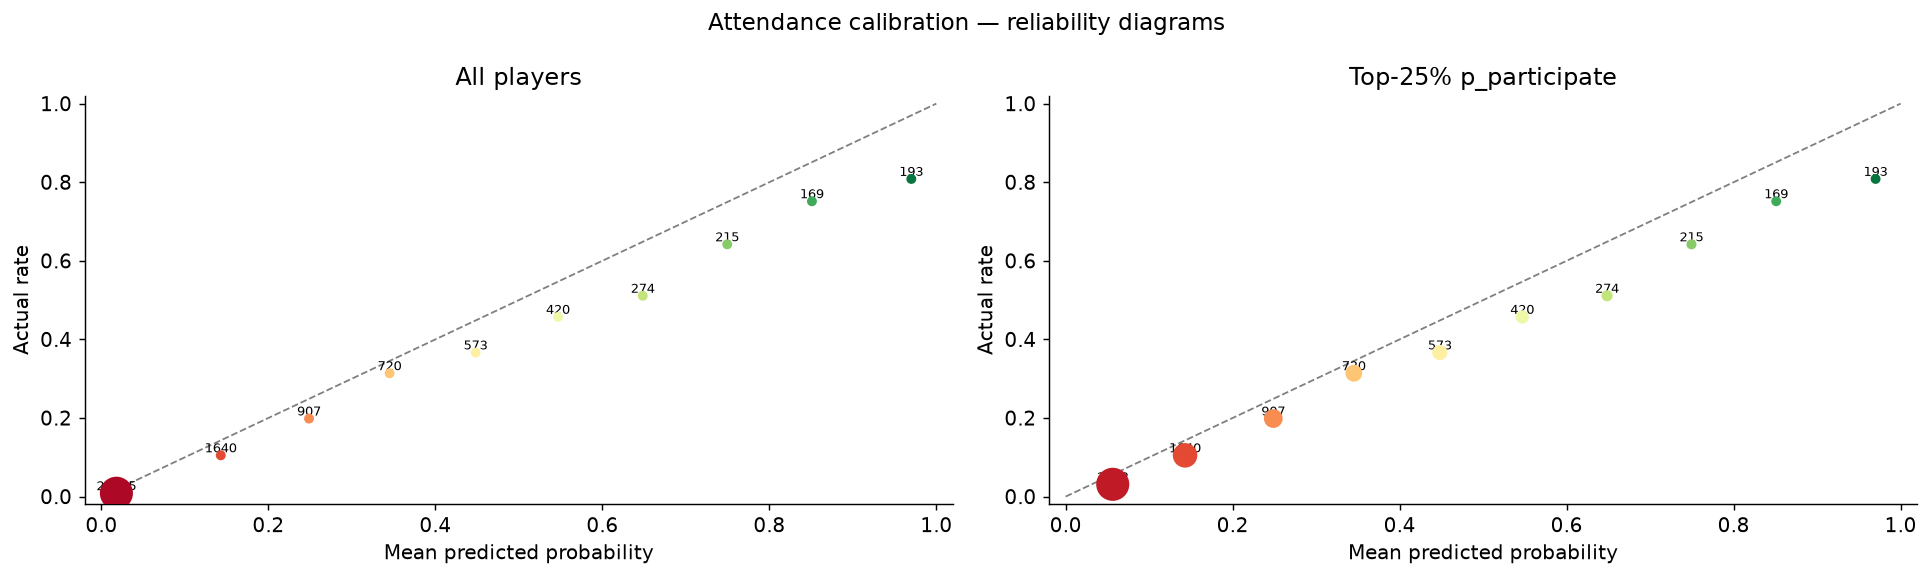

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
reliability_diagram(df['participated'],              df['p_participate'],             axes[0], 'All players')
reliability_diagram(df[df['p_participate'] >= q75]['participated'], df[df['p_participate'] >= q75]['p_participate'], axes[1], 'Top-25% p_participate')
fig.suptitle('Attendance calibration — reliability diagrams', fontsize=13)
plt.tight_layout()
plt.show()

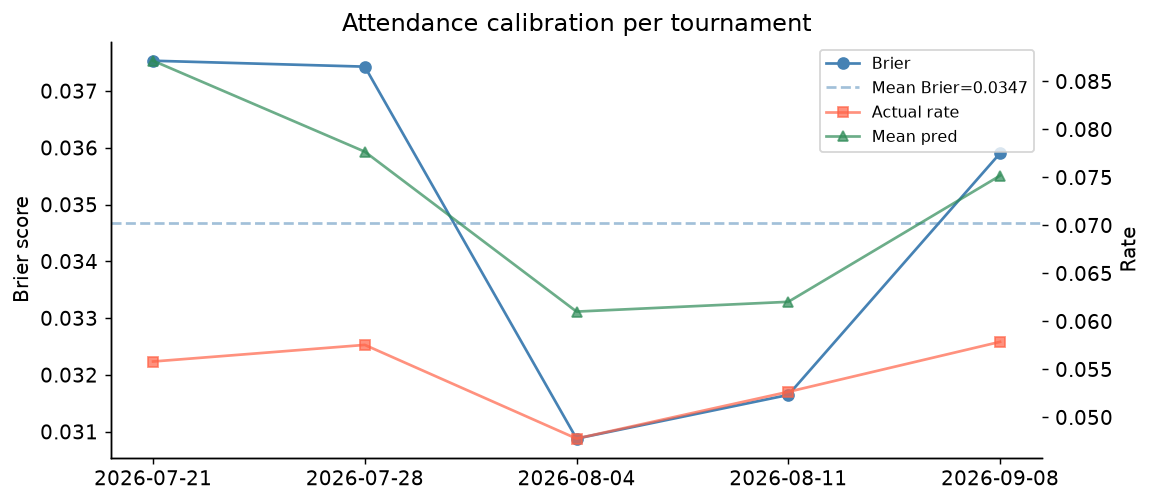

tourn_date   brier  actual_rate  mean_pred
2026-07-21 0.03753      0.05582    0.08716
2026-07-28 0.03743      0.05755    0.07768
2026-08-04 0.03088      0.04779    0.06102
2026-08-11 0.03165      0.05266    0.06204
2026-09-08 0.03590      0.05787    0.07518


In [11]:
# Per-tournament trend
tourn_att = df.groupby('tourn_date').apply(lambda g: pd.Series({
    'brier':       np.mean((g['p_participate'] - g['participated'])**2),
    'actual_rate': g['participated'].mean(),
    'mean_pred':   g['p_participate'].mean(),
})).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tourn_att['tourn_date'], tourn_att['brier'], marker='o', color='steelblue', label='Brier')
ax.axhline(tourn_att['brier'].mean(), ls='--', color='steelblue', alpha=0.5,
           label=f"Mean Brier={tourn_att['brier'].mean():.4f}")
ax2 = ax.twinx()
ax2.plot(tourn_att['tourn_date'], tourn_att['actual_rate'], 's-', color='tomato',  alpha=0.7, label='Actual rate')
ax2.plot(tourn_att['tourn_date'], tourn_att['mean_pred'],   '^-', color='seagreen', alpha=0.7, label='Mean pred')
ax.set_ylabel('Brier score')
ax2.set_ylabel('Rate')
ax.set_title('Attendance calibration per tournament')
plt.xticks(rotation=30)
lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(lines, labels, fontsize=9)
plt.tight_layout()
plt.show()
print(tourn_att.round(5).to_string(index=False))

---
## 3 — Top-N Conditional Calibration
For players who actually played, how accurate are `P_topN_given_play` predictions?

In [12]:
played = df[df['participated'] == 1].copy()
print(f"Participating player-tournament rows: {len(played):,}")

topn_stats = []
for n in N_VALS:
    s = calibration_stats(played[f'in_top{n}'], played[f'P_top{n}_given_play'], label=f'Top-{n} | played')
    naive_p = played[f'in_top{n}'].mean()
    s['naive_brier'] = naive_p * (1 - naive_p)
    s['brier_skill'] = 1 - s['brier'] / s['naive_brier']
    topn_stats.append(s)

topn_df = pd.DataFrame(topn_stats)
print(topn_df[['label', 'n', 'brier', 'ece', 'logloss', 'brier_skill']].round(5).to_string(index=False))

Participating player-tournament rows: 1,782
         label    n   brier     ece  logloss  brier_skill
Top-1 | played 1782 0.00247 0.00080  0.01246      0.11807
Top-3 | played 1782 0.00716 0.00405  0.03506      0.14176
Top-5 | played 1782 0.01126 0.00447  0.05132      0.18616
Top-8 | played 1782 0.01656 0.00550  0.06995      0.24523


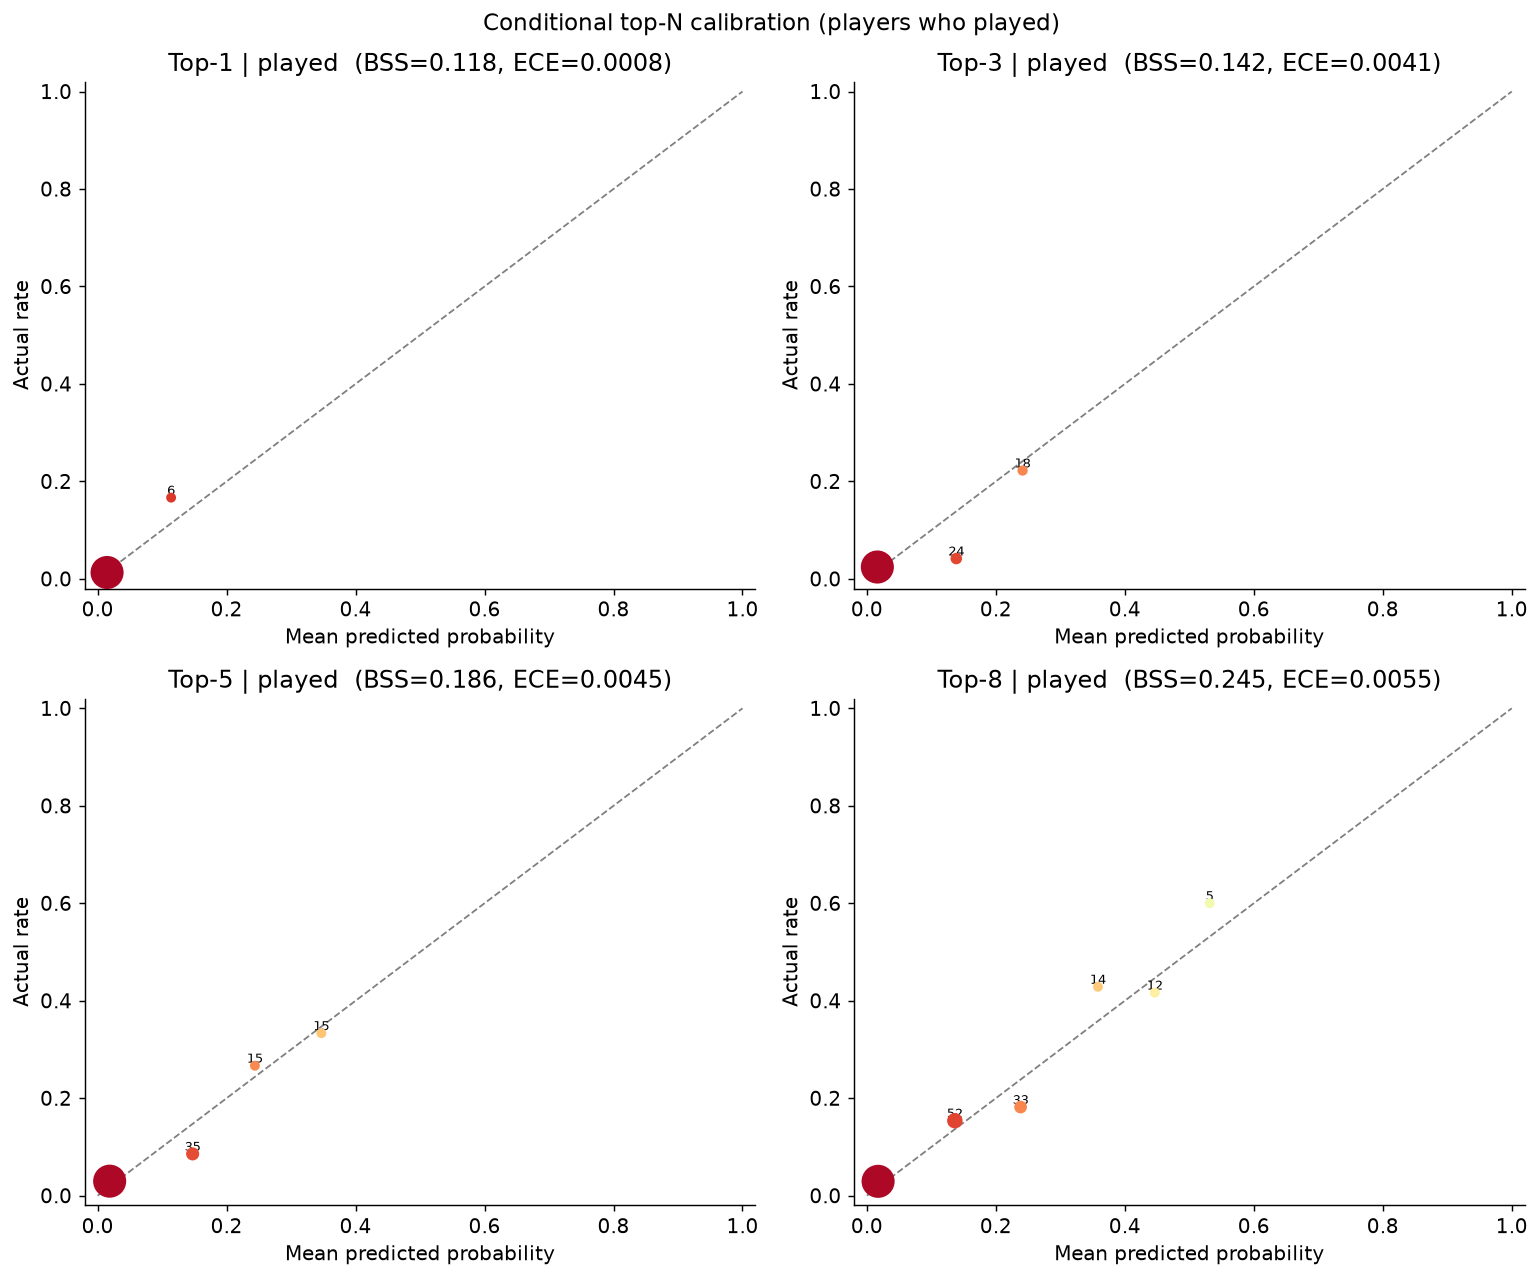

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, n in enumerate(N_VALS):
    s = topn_df[topn_df['label'] == f'Top-{n} | played'].iloc[0]
    reliability_diagram(
        played[f'in_top{n}'], played[f'P_top{n}_given_play'], axes[i],
        title=f'Top-{n} | played  (BSS={s["brier_skill"]:.3f}, ECE={s["ece"]:.4f})'
    )
fig.suptitle('Conditional top-N calibration (players who played)', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# Systematic over/underconfidence
print("Mean predicted vs. mean actual (for participating players):")
print(f"{'N':>4}  {'Mean predicted':>16}  {'Mean actual':>14}  {'Bias (pred-act)':>16}")
for n in N_VALS:
    mp = played[f'P_top{n}_given_play'].mean()
    ma = played[f'in_top{n}'].mean()
    print(f"{n:>4}  {mp:>16.5f}  {ma:>14.5f}  {mp-ma:>+16.5f}")

Mean predicted vs. mean actual (for participating players):
   N    Mean predicted     Mean actual   Bias (pred-act)
   1           0.00242         0.00281          -0.00038
   3           0.00736         0.00842          -0.00105
   5           0.01227         0.01403          -0.00176
   8           0.01944         0.02245          -0.00301


---
## 4 — Unconditional Probability Calibration
Calibration of `p_participate x P_topN_given_play` — the actual fair value used for betting.

In [15]:
uncond_stats = []
for n in N_VALS:
    sub = df[df[f'p_top{n}'] > 0.001]
    s   = calibration_stats(sub[f'in_top{n}'], sub[f'p_top{n}'], label=f'Top-{n} unconditional')
    naive_p = sub[f'in_top{n}'].mean()
    s['naive_brier'] = naive_p * (1 - naive_p)
    s['brier_skill'] = 1 - s['brier'] / s['naive_brier']
    uncond_stats.append(s)

uncond_df = pd.DataFrame(uncond_stats)
print(uncond_df[['label', 'n', 'brier', 'ece', 'logloss', 'brier_skill']].round(5).to_string(index=False))

              label    n   brier     ece  logloss  brier_skill
Top-1 unconditional  310 0.01284 0.00644  0.06839     -0.00805
Top-3 unconditional  587 0.02257 0.00753  0.10402      0.03073
Top-5 unconditional  786 0.02574 0.01047  0.10342      0.09392
Top-8 unconditional 1109 0.02763 0.00599  0.10346      0.14330


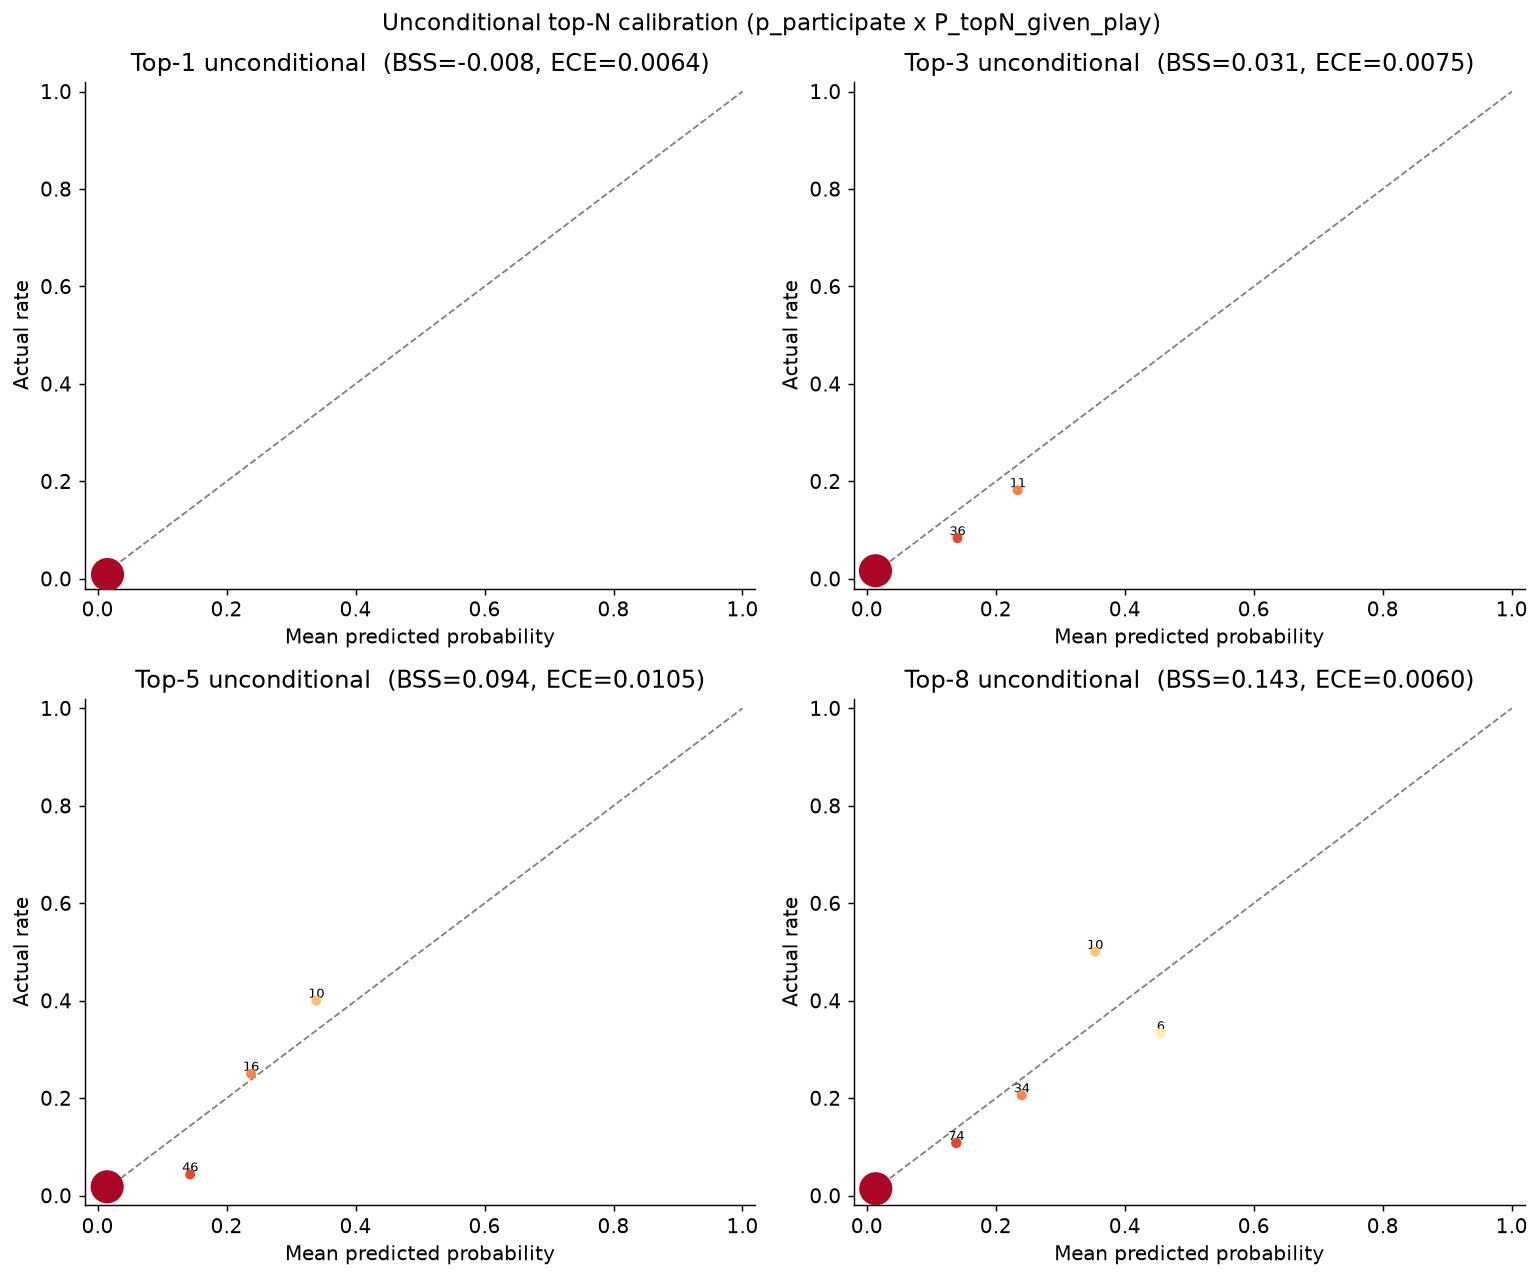

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, n in enumerate(N_VALS):
    sub = df[df[f'p_top{n}'] > 0.001]
    s   = uncond_df[uncond_df['label'] == f'Top-{n} unconditional'].iloc[0]
    reliability_diagram(
        sub[f'in_top{n}'], sub[f'p_top{n}'], axes[i],
        title=f'Top-{n} unconditional  (BSS={s["brier_skill"]:.3f}, ECE={s["ece"]:.4f})'
    )
fig.suptitle('Unconditional top-N calibration (p_participate x P_topN_given_play)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5 — Blind Spots & Structural Weaknesses

In [25]:
# Per-player calibration stats
player_stats = df.groupby('username').apply(lambda g: pd.Series({
    'n_played':          g['participated'].sum(),
    'p_participate_mean': g['p_participate'].mean(),
    'actual_att_rate':   g['participated'].mean(),
    'attend_bias':       g['p_participate'].mean() - g['participated'].mean(),
    'top8_pred_mean':    g['p_top8'].mean(),
    'top8_actual':       g['in_top8'].mean(),
    'top8_brier':        np.mean((g['p_top8'] - g['in_top8'])**2),
    'top3_pred_mean':    g['p_top3'].mean(),
    'top3_actual':       g['in_top3'].mean(),
})).reset_index()
player_stats['player_name'] = player_stats['username'].map(username_to_player).fillna(player_stats['username'])
active = player_stats[player_stats['n_played'] >= 1].copy()
print(f"Players with >=3 appearances: {len(active)}")

Players with >=3 appearances: 899


In [27]:
print("=== Over-predicted attendance (model thinks they attend more than they do) ===")
cols = ['player_name', 'n_played', 'p_participate_mean', 'actual_att_rate', 'attend_bias']
print(active.nlargest(15, 'attend_bias')[cols].round(4).to_string(index=False))
print()
print("=== Under-predicted attendance ===")
print(active.nsmallest(15, 'attend_bias')[cols].round(4).to_string(index=False))

=== Over-predicted attendance (model thinks they attend more than they do) ===
                    player_name  n_played  p_participate_mean  actual_att_rate  attend_bias
          Vladimir Mikhailovsky       1.0              0.7466              0.2       0.5466
              Phuong Hanh Luong       1.0              0.6609              0.2       0.4609
          Matthias Mattenberger       1.0              0.6565              0.2       0.4565
                  Kirill Klukin       2.0              0.8089              0.4       0.4089
               Timofey Beznosov       1.0              0.6001              0.2       0.4001
                Hong Anh Nguyen       1.0              0.5972              0.2       0.3972
         Vasileios Dim Katsanis       1.0              0.5955              0.2       0.3955
          Oscar Humberto Ardila       2.0              0.7899              0.4       0.3899
      Tyrhhone James Tabernilla       1.0              0.5878              0.2       0.3878
 

In [30]:
print("=== Highest top-3 Brier score (worst per-player calibration) ===")
cols3 = ['player_name', 'n_played', 'top8_pred_mean', 'top8_actual', 'top8_brier']
print(active.nlargest(20, 'top8_brier')[cols3].round(4).to_string(index=False))

=== Highest top-3 Brier score (worst per-player calibration) ===
           player_name  n_played  top8_pred_mean  top8_actual  top8_brier
    Zhamsaran Tsydypov       4.0          0.2391          0.6      0.3663
        Rudik Makarian       4.0          0.0702          0.4      0.3559
        Aleksei Sarana       5.0          0.4680          0.4      0.2693
         Jeffery Xiong       5.0          0.2732          0.4      0.2603
          Hans Niemann       4.0          0.2249          0.4      0.2082
       Artem Avanesian       2.0          0.0105          0.2      0.2006
     Akshay Borgaonkar       3.0          0.0086          0.2      0.2004
          Tobias Kölle       1.0          0.0001          0.2      0.2000
      Nitzan Steinberg       4.0          0.0086          0.2      0.1996
      Alireza Firouzja       2.0          0.0940          0.2      0.1939
        Arjun Erigaisi       3.0          0.2294          0.4      0.1935
        Maxim Matlakov       2.0          0.035

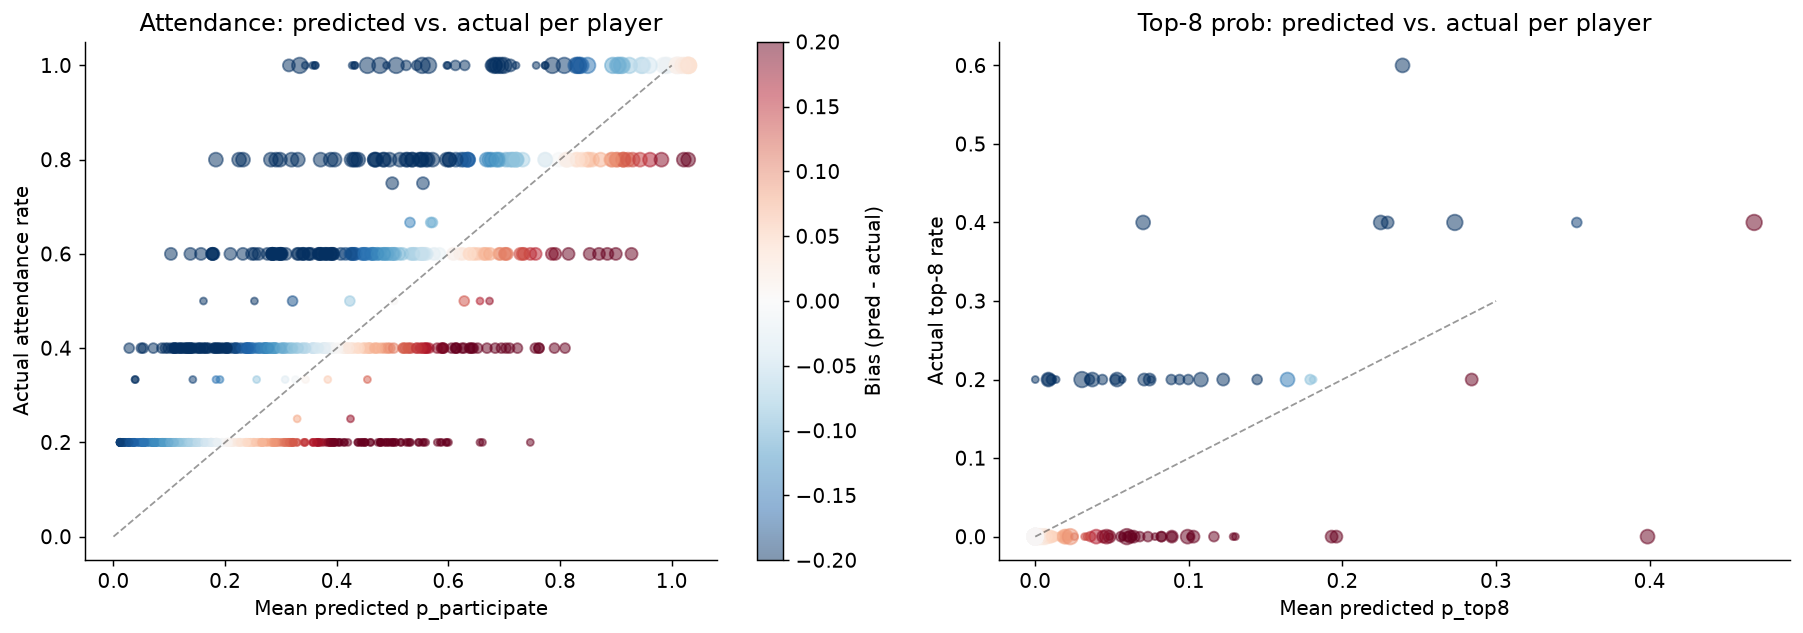

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    active['p_participate_mean'], active['actual_att_rate'],
    alpha=0.5, s=active['n_played'] * 15,
    c=active['attend_bias'], cmap='RdBu_r', vmin=-0.2, vmax=0.2
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
axes[0].set_xlabel('Mean predicted p_participate')
axes[0].set_ylabel('Actual attendance rate')
axes[0].set_title('Attendance: predicted vs. actual per player')
plt.colorbar(sc, ax=axes[0], label='Bias (pred - actual)')

axes[1].scatter(
    active['top8_pred_mean'], active['top8_actual'],
    alpha=0.5, s=active['n_played'] * 15,
    c=active['top8_pred_mean'] - active['top8_actual'], cmap='RdBu_r', vmin=-0.05, vmax=0.05
)
axes[1].plot([0, 0.3], [0, 0.3], 'k--', lw=1, alpha=0.4)
axes[1].set_xlabel('Mean predicted p_top8')
axes[1].set_ylabel('Actual top-8 rate')
axes[1].set_title('Top-8 prob: predicted vs. actual per player')

plt.tight_layout()
plt.show()

In [34]:
# Attendance-altered players: did manual overrides go in the right direction?
alt_players = df[df['attendance_altered'] == 1].copy()
if len(alt_players) == 0:
    print('No attendance-altered players found in this period.')
else:
    alt_summary = alt_players.groupby('username').apply(lambda g: pd.Series({
        'appearances': len(g),
        'n_played':    g['participated'].sum(),
        'mean_adj_p':  g['p_participate'].mean(),
        'actual_rate': g['participated'].mean(),
    })).reset_index()
    alt_summary['player_name'] = alt_summary['username'].map(username_to_player).fillna(alt_summary['username'])
    print(f"Attendance-altered players: {len(alt_summary)}")
    print(alt_summary.sort_values('mean_adj_p', ascending=False)[
        ['player_name', 'appearances', 'n_played', 'mean_adj_p', 'actual_rate']
    ].round(4).to_string(index=False))

No attendance-altered players found in this period.


---
## 6 — Betting P&L
Actual fills from `~/.kalshi/data/kalshi.db`, scoped to Titled Tuesday markets only.

In [35]:
conn2 = sqlite3.connect(FILLS_DB)
fills_raw = pd.read_sql_query(
    "SELECT * FROM fills WHERE ticker LIKE 'KXTITLEDTUES%' ORDER BY created_time",
    conn2
)
conn2.close()

_WINNER_RE = re.compile(r'^KXTITLEDTUESDAY-(\d{2}[A-Z]{3}\d{2})-([A-Z]+)$')
_TOPN_RE   = re.compile(r'^KXTITLEDTUESTOP-(\d{2}[A-Z]{3}\d{2})T(\d+)-([A-Z]+)$')
_MONTH_MAP = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
              'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}

def parse_ticker(ticker):
    m = _WINNER_RE.match(ticker)
    if m:
        return m.group(1), 1, m.group(2)
    m = _TOPN_RE.match(ticker)
    if m:
        return m.group(1), int(m.group(2)), m.group(3)
    return None, None, None

def kalshi_date_to_iso(d):
    return f"20{d[:2]}-{_MONTH_MAP[d[2:5]]:02d}-{int(d[5:]):02d}"

fills = fills_raw.copy()
fills[['kalshi_date', 'n', 'code']] = fills['ticker'].apply(
    lambda t: pd.Series(parse_ticker(t))
)
fills['tourn_date']  = fills['kalshi_date'].apply(lambda d: kalshi_date_to_iso(d) if pd.notna(d) else None)
fills['player_name'] = fills['code'].map(code_to_player)
fills['username']    = fills['player_name'].map(player_to_username)

unmapped = fills[fills['player_name'].isna()]['code'].unique()
print(f"Total TT fills : {len(fills):,}")
print(f"Unmapped codes : {len(unmapped)} -> {sorted(unmapped)}")
print(f"Date range     : {fills['tourn_date'].min()} to {fills['tourn_date'].max()}")

Total TT fills : 1,683
Unmapped codes : 16 -> ['AASH', 'AAVA', 'ABOR', 'AFIR', 'ALIA', 'AUSO', 'CYOO', 'DANT', 'HXUE', 'LLE', 'MKRA', 'MMAT', 'NSON', 'NSTE', 'RMAK', 'ZNUR']
Date range     : 2026-07-07 to 2026-09-15


In [36]:
# Determine outcome for each fill from standings
conn = sqlite3.connect(DB_PATH)
all_standings = pd.read_sql_query(
    "SELECT date, username, rank FROM titled_tuesday_standings WHERE date >= ?",
    conn, params=(LIVE_START,)
)
conn.close()
all_standings['date'] = all_standings['date'].str[:10]

# Build (tourn_date, username, n) -> outcome lookup
outcome_lookup = {}
for _, row in all_standings.iterrows():
    for n in [1, 3, 5, 8]:
        outcome_lookup[(row['date'], row['username'], n)] = int(row['rank'] <= n)
settled_dates = set(all_standings['date'].unique())

def get_outcome(tourn_date, username, n):
    if pd.isna(username) or pd.isna(tourn_date) or pd.isna(n):
        return None
    n = int(n)
    if tourn_date not in settled_dates:
        return None  # unsettled
    return outcome_lookup.get((tourn_date, username, n), 0)  # not in standings -> didn't play -> 0

fills['outcome'] = fills.apply(lambda r: get_outcome(r['tourn_date'], r['username'], r['n']), axis=1)
print(f"Fills with known outcome  : {fills['outcome'].notna().sum():,} / {len(fills):,}")
print(f"Fills pending/unmapped    : {fills['outcome'].isna().sum():,}")

Fills with known outcome  : 1,526 / 1,683
Fills pending/unmapped    : 157


In [37]:
# P&L calculation
# buy:  pnl = bettor_wins * count - price * count - fee
# sell: pnl = price * count - bettor_wins * count - fee
# Combined, buy+sell pair correctly yields (sell_price - buy_price) * count

f = fills[fills['outcome'].notna()].copy()
f['price']       = np.where(f['side'] == 'yes', f['yes_price'], f['no_price'])
f['bettor_wins'] = np.where(f['side'] == 'yes', f['outcome'], 1 - f['outcome']).astype(float)
sign             = np.where(f['action'] == 'buy', 1.0, -1.0)
f['pnl']         = sign * (f['bettor_wins'] * f['count'] - f['price'] * f['count']) - f['fee_cost']
f['gross_cost']  = np.where(f['action'] == 'buy', f['price'] * f['count'] + f['fee_cost'], 0.0)

total_pnl  = f['pnl'].sum()
total_cost = f[f['action'] == 'buy']['gross_cost'].sum()
roi        = total_pnl / total_cost if total_cost > 0 else float('nan')

print("=== Overall P&L ===")
print(f"  Net P&L        : ${total_pnl:+.2f}")
print(f"  Total invested  : ${total_cost:.2f}  (sum of buy costs incl. fees)")
print(f"  Total fees      : ${f['fee_cost'].sum():.2f}")
print(f"  ROI             : {roi:.1%}")
print(f"  Fills analyzed  : {len(f):,}")

=== Overall P&L ===
  Net P&L        : $+9158.76
  Total invested  : $23521.00  (sum of buy costs incl. fees)
  Total fees      : $561.93
  ROI             : 38.9%
  Fills analyzed  : 1,526


In [38]:
# P&L breakdown by market type, maker/taker, action, side
breakdowns = []
for n_val, grp in f.groupby('n'):
    label = 'Winner (N=1)' if n_val == 1 else f'Top-{int(n_val)}'
    cost  = grp[grp['action'] == 'buy']['gross_cost'].sum()
    breakdowns.append({'group': 'Market type', 'label': label, 'n_fills': len(grp),
                       'pnl': grp['pnl'].sum(), 'cost': cost,
                       'roi': grp['pnl'].sum() / cost if cost else float('nan')})

for is_taker, grp in f.groupby('is_taker'):
    label = 'Taker' if is_taker else 'Maker'
    cost  = grp[grp['action'] == 'buy']['gross_cost'].sum()
    breakdowns.append({'group': 'Order type', 'label': label, 'n_fills': len(grp),
                       'pnl': grp['pnl'].sum(), 'cost': cost,
                       'roi': grp['pnl'].sum() / cost if cost else float('nan')})

for action, grp in f.groupby('action'):
    cost = grp['gross_cost'].sum()
    breakdowns.append({'group': 'Action', 'label': action.capitalize(), 'n_fills': len(grp),
                       'pnl': grp['pnl'].sum(), 'cost': cost,
                       'roi': grp['pnl'].sum() / cost if cost else float('nan')})

for side_val, grp in f.groupby('side'):
    cost = grp[grp['action'] == 'buy']['gross_cost'].sum()
    breakdowns.append({'group': 'Side', 'label': side_val.upper(), 'n_fills': len(grp),
                       'pnl': grp['pnl'].sum(), 'cost': cost,
                       'roi': grp['pnl'].sum() / cost if cost else float('nan')})

bkdn_df = pd.DataFrame(breakdowns)
bkdn_df[['pnl', 'cost', 'roi']] = bkdn_df[['pnl', 'cost', 'roi']].round(3)
print(bkdn_df.to_string(index=False))

      group        label  n_fills      pnl      cost   roi
Market type Winner (N=1)      420 1161.398  4837.833 0.240
Market type        Top-3      297  291.834  3454.157 0.084
Market type        Top-5      264 3544.035  3682.824 0.962
Market type        Top-8      525 4104.673 11243.266 0.365
Market type       Top-10       20   56.822   302.924 0.188
 Order type        Maker      627  631.802  5635.051 0.112
 Order type        Taker      899 8526.960 17885.952 0.477
     Action          Buy     1242 8388.416 23521.004 0.357
     Action         Sell      284  770.346     0.000   NaN
       Side           NO      539 2997.086 13823.520 0.217
       Side          YES      987 6161.676  9697.484 0.635


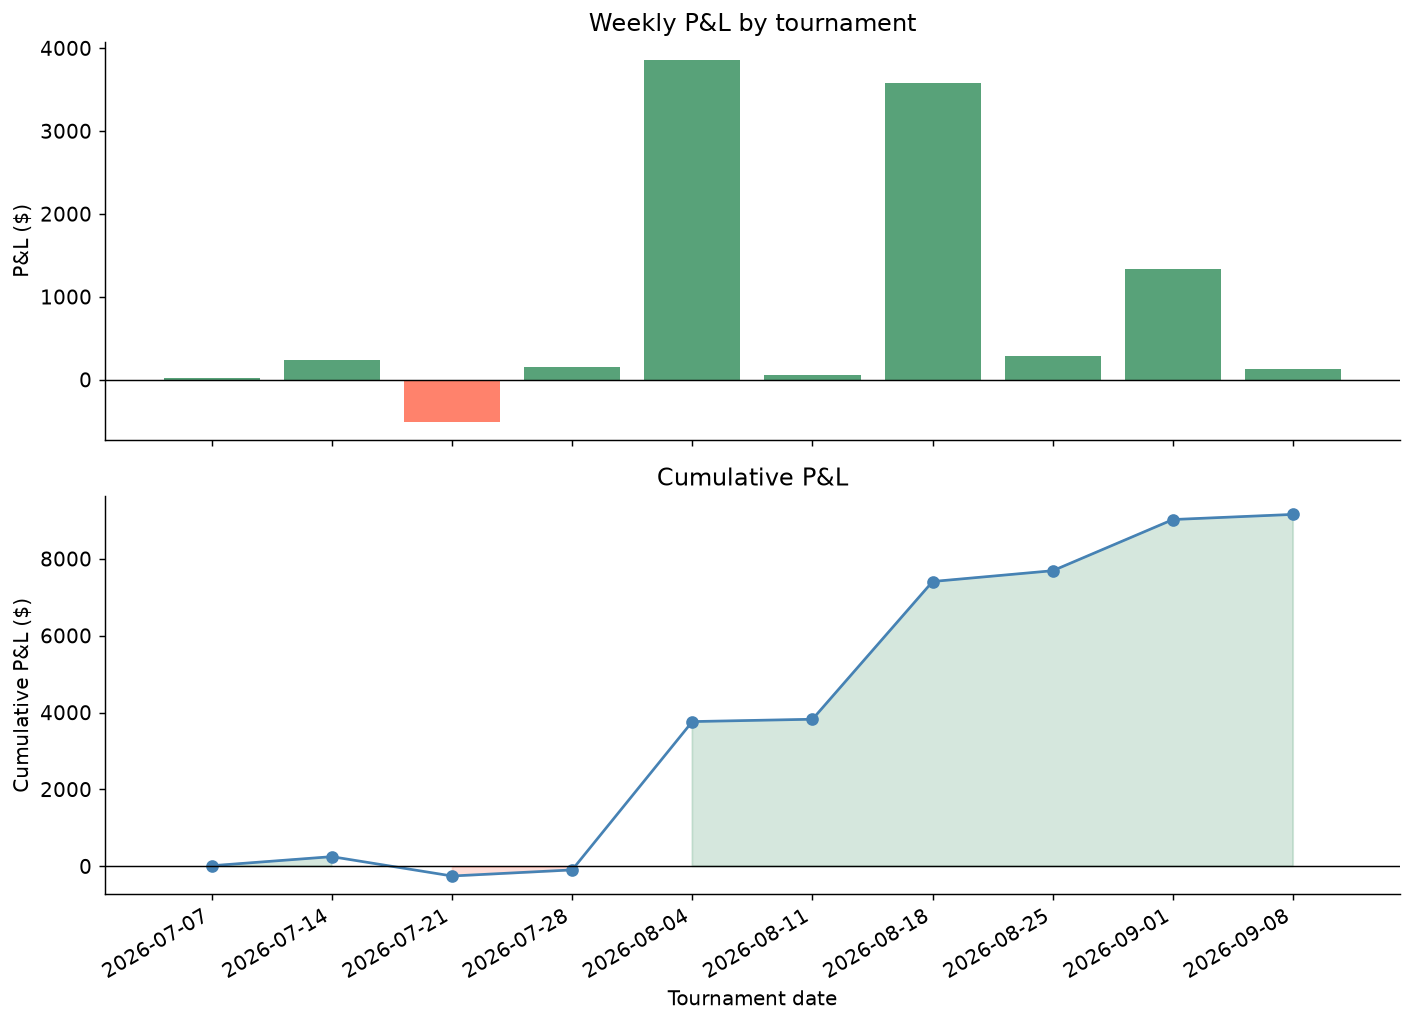

tourn_date      pnl     cost  n_fills    roi  cumulative_pnl
2026-07-07   16.313  393.434       36  0.041          16.313
2026-07-14  236.080 1601.112      109  0.147         252.392
2026-07-21 -503.587 1864.610      190 -0.270        -251.195
2026-07-28  158.650 3265.302      142  0.049         -92.546
2026-08-04 3859.805 2818.891      198  1.369        3767.260
2026-08-11   60.902 4382.559      226  0.014        3828.162
2026-08-18 3584.294 3029.492      175  1.183        7412.456
2026-08-25  281.158 1851.114       94  0.152        7693.614
2026-09-01 1331.608 2896.291      158  0.460        9025.222
2026-09-08  133.541 1418.199      198  0.094        9158.762


In [39]:
# Weekly P&L trend
weekly = f.groupby('tourn_date').agg(
    pnl=('pnl', 'sum'), cost=('gross_cost', 'sum'), n_fills=('pnl', 'count')
).reset_index()
weekly['roi']            = weekly['pnl'] / weekly['cost']
weekly['cumulative_pnl'] = weekly['pnl'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
colors = ['seagreen' if p >= 0 else 'tomato' for p in weekly['pnl']]
axes[0].bar(weekly['tourn_date'], weekly['pnl'], color=colors, alpha=0.8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('P&L ($)')
axes[0].set_title('Weekly P&L by tournament')

axes[1].plot(weekly['tourn_date'], weekly['cumulative_pnl'], marker='o', color='steelblue')
axes[1].fill_between(weekly['tourn_date'], 0, weekly['cumulative_pnl'],
                     where=weekly['cumulative_pnl'] >= 0, alpha=0.2, color='seagreen')
axes[1].fill_between(weekly['tourn_date'], 0, weekly['cumulative_pnl'],
                     where=weekly['cumulative_pnl'] < 0, alpha=0.2, color='tomato')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Cumulative P&L ($)')
axes[1].set_xlabel('Tournament date')
axes[1].set_title('Cumulative P&L')
for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(weekly.round(3).to_string(index=False))

In [40]:
# Edge analysis: for buy fills, was the model fair value higher than the price paid?
pred_cols = {1: 'p_top1', 3: 'p_top3', 5: 'p_top5', 8: 'p_top8'}

buys = f[f['action'] == 'buy'].copy()
buys['n_int'] = buys['n'].astype(int)
buys = buys.merge(
    df[['tourn_date', 'username', 'p_top1', 'p_top3', 'p_top5', 'p_top8']],
    on=['tourn_date', 'username'], how='left'
)

def get_fair_value(row):
    n = int(row['n_int']) if not pd.isna(row['n_int']) else None
    col = pred_cols.get(n)
    return row[col] if col and col in row.index else float('nan')

buys['model_fair'] = buys.apply(get_fair_value, axis=1)
buys['edge'] = np.where(
    buys['side'] == 'yes',
    buys['model_fair'] - buys['yes_price'],
    (1 - buys['model_fair']) - buys['no_price']
)

matched = buys[buys['model_fair'].notna()]
print(f"Buy fills matched to predictions : {len(matched):,} / {len(buys):,}")
print(f"Mean edge at time of fill        : {matched['edge'].mean():.4f}")
print(f"Fills with positive edge         : {(matched['edge'] > 0).mean():.1%}")
print()
for n_val, grp in matched.groupby('n_int'):
    label = 'Winner' if n_val == 1 else f'Top-{int(n_val)}'
    print(f"  {label:8s}: mean edge={grp['edge'].mean():.4f}, "
          f"pct positive={(grp['edge'] > 0).mean():.1%}, n={len(grp)}")

Buy fills matched to predictions : 788 / 1,242
Mean edge at time of fill        : 0.0532
Fills with positive edge         : 85.4%

  Winner  : mean edge=0.0401, pct positive=82.8%, n=261
  Top-3   : mean edge=0.0423, pct positive=89.8%, n=166
  Top-5   : mean edge=0.0741, pct positive=92.2%, n=129
  Top-8   : mean edge=0.0642, pct positive=81.5%, n=232


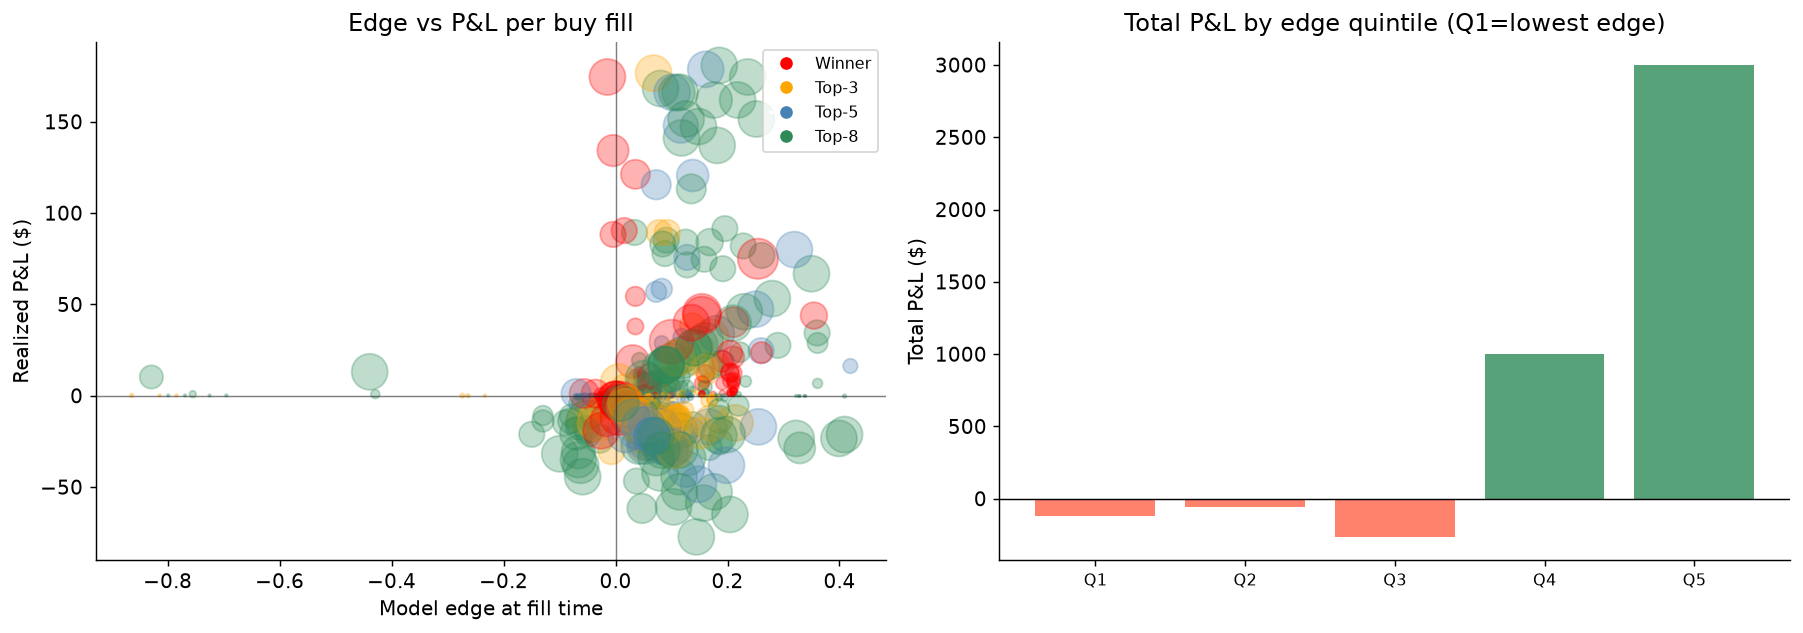

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_map = {1: 'red', 3: 'orange', 5: 'steelblue', 8: 'seagreen'}
c_vec = matched['n_int'].map(color_map)
axes[0].scatter(matched['edge'], matched['pnl'], alpha=0.3, s=matched['count'] * 2, c=c_vec)
axes[0].axhline(0, color='black', lw=0.8, alpha=0.5)
axes[0].axvline(0, color='black', lw=0.8, alpha=0.5)
axes[0].set_xlabel('Model edge at fill time')
axes[0].set_ylabel('Realized P&L ($)')
axes[0].set_title('Edge vs P&L per buy fill')

from matplotlib.lines import Line2D
axes[0].legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor=col, label=lbl, markersize=8)
    for lbl, col in [('Winner','red'),('Top-3','orange'),('Top-5','steelblue'),('Top-8','seagreen')]
], fontsize=9)

clean = matched[matched['edge'].notna() & np.isfinite(matched['edge'])].copy()
if len(clean) >= 5:
    clean['edge_quintile'] = pd.qcut(clean['edge'], q=5, duplicates='drop')
    eq = clean.groupby('edge_quintile', observed=True)['pnl'].sum()
    colors = ['seagreen' if v >= 0 else 'tomato' for v in eq]
    axes[1].bar(range(len(eq)), eq.values, color=colors, alpha=0.8)
    axes[1].set_xticks(range(len(eq)))
    axes[1].set_xticklabels([f'Q{i+1}' for i in range(len(eq))], fontsize=9)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_ylabel('Total P&L ($)')
    axes[1].set_title('Total P&L by edge quintile (Q1=lowest edge)')

plt.tight_layout()
plt.show()

In [42]:
# Best and worst individual buy bets
buys_settled = buys[buys['outcome'].notna()].copy()
disp_cols = ['ticker', 'tourn_date', 'player_name', 'side', 'count', 'price', 'bettor_wins', 'pnl', 'edge']
avail = [c for c in disp_cols if c in buys_settled.columns]

print("=== Top 10 best bets ===")
print(buys_settled.nlargest(10, 'pnl')[avail].round(3).to_string(index=False))
print()
print("=== Top 10 worst bets ===")
print(buys_settled.nsmallest(10, 'pnl')[avail].round(3).to_string(index=False))

=== Top 10 best bets ===
                        ticker tourn_date        player_name side  count  price  bettor_wins     pnl   edge
KXTITLEDTUESTOP-26AUG04T8-HNIE 2026-08-04       Hans Niemann  yes  200.0   0.09          1.0 180.853  0.185
KXTITLEDTUESTOP-26JUL14T8-PMAG 2026-07-14 Parham Maghsoodloo  yes  200.0   0.10          1.0 178.740    NaN
KXTITLEDTUESTOP-26AUG18T3-AERI 2026-08-18     Arjun Erigaisi  yes  200.0   0.10          1.0 178.740    NaN
KXTITLEDTUESTOP-26AUG18T3-AERI 2026-08-18     Arjun Erigaisi  yes  200.0   0.10          1.0 178.740    NaN
KXTITLEDTUESTOP-26AUG18T3-AERI 2026-08-18     Arjun Erigaisi  yes  200.0   0.10          1.0 178.740    NaN
KXTITLEDTUESTOP-26SEP08T5-HNIE 2026-09-08       Hans Niemann  yes  200.0   0.10          1.0 178.740  0.161
KXTITLEDTUESTOP-26AUG04T3-MCAR 2026-08-04     Magnus Carlsen  yes  200.0   0.11          1.0 176.629  0.068
KXTITLEDTUESTOP-26AUG25T3-AERI 2026-08-25     Arjun Erigaisi  yes  200.0   0.11          1.0 176.629    NaN
  K

---
## 7 — Backtest vs. Live Comparison
Does live calibration track the walk-forward backtest, or has it diverged?

In [43]:
BACKTEST_WINDOW_START = '2026-01-01'
BACKTEST_WINDOW_END   = '2026-07-06'

conn = sqlite3.connect(DB_PATH)
bt = pd.read_sql_query("""
    SELECT model, date, username, participated,
           p_participate, p_top1, p_top3, p_top8,
           in_top1, in_top3, in_top8
    FROM backtest_results
    WHERE date BETWEEN ? AND ?
""", conn, params=(BACKTEST_WINDOW_START, BACKTEST_WINDOW_END))
conn.close()
print(f"Backtest rows : {len(bt):,} | models : {list(bt['model'].unique())} | tournaments : {bt['date'].nunique()}")

Backtest rows : 1,106,072 | models : ['decay', 'gradient_boost', 'logistic', 'random_forest'] | tournaments : 26


In [44]:
# Brier score comparison: each backtest model vs live
compare_metrics = [
    ('p_participate', 'participated', 'Attendance'),
    ('p_top1',        'in_top1',      'Top-1'),
    ('p_top3',        'in_top3',      'Top-3'),
    ('p_top8',        'in_top8',      'Top-8'),
]

rows = []
for pred_col, true_col, label in compare_metrics:
    # Backtest models
    for model, grp in bt.groupby('model'):
        valid = grp[[pred_col, true_col]].dropna()
        if pred_col != 'p_participate':
            valid = valid[valid[pred_col] > 0.001]
        if len(valid) < 100:
            continue
        rows.append({'metric': label, 'source': f'BT:{model}',
                     **calibration_stats(valid[true_col], valid[pred_col])})
    # Live
    live_pred_col = pred_col  # same column names in df
    valid_live = df[[live_pred_col, true_col]].dropna()
    if pred_col != 'p_participate':
        valid_live = valid_live[valid_live[live_pred_col] > 0.001]
    if len(valid_live) >= 5:
        rows.append({'metric': label, 'source': 'LIVE',
                     **calibration_stats(valid_live[true_col], valid_live[live_pred_col])})

comp_df = pd.DataFrame(rows)
pivot   = comp_df.pivot_table(index='metric', columns='source', values='brier', aggfunc='mean')
print("Brier scores by metric and source (lower = better):")
print(pivot.round(6).to_string())

Brier scores by metric and source (lower = better):
source      BT:decay  BT:gradient_boost  BT:logistic  BT:random_forest      LIVE
metric                                                                          
Attendance  0.023155           0.025184     0.027609          0.028035  0.034425
Top-1       0.015517           0.014797     0.015003          0.014559  0.012839
Top-3       0.026593           0.026674     0.027106          0.027047  0.022566
Top-8       0.039416           0.040677     0.042413          0.042478  0.027629


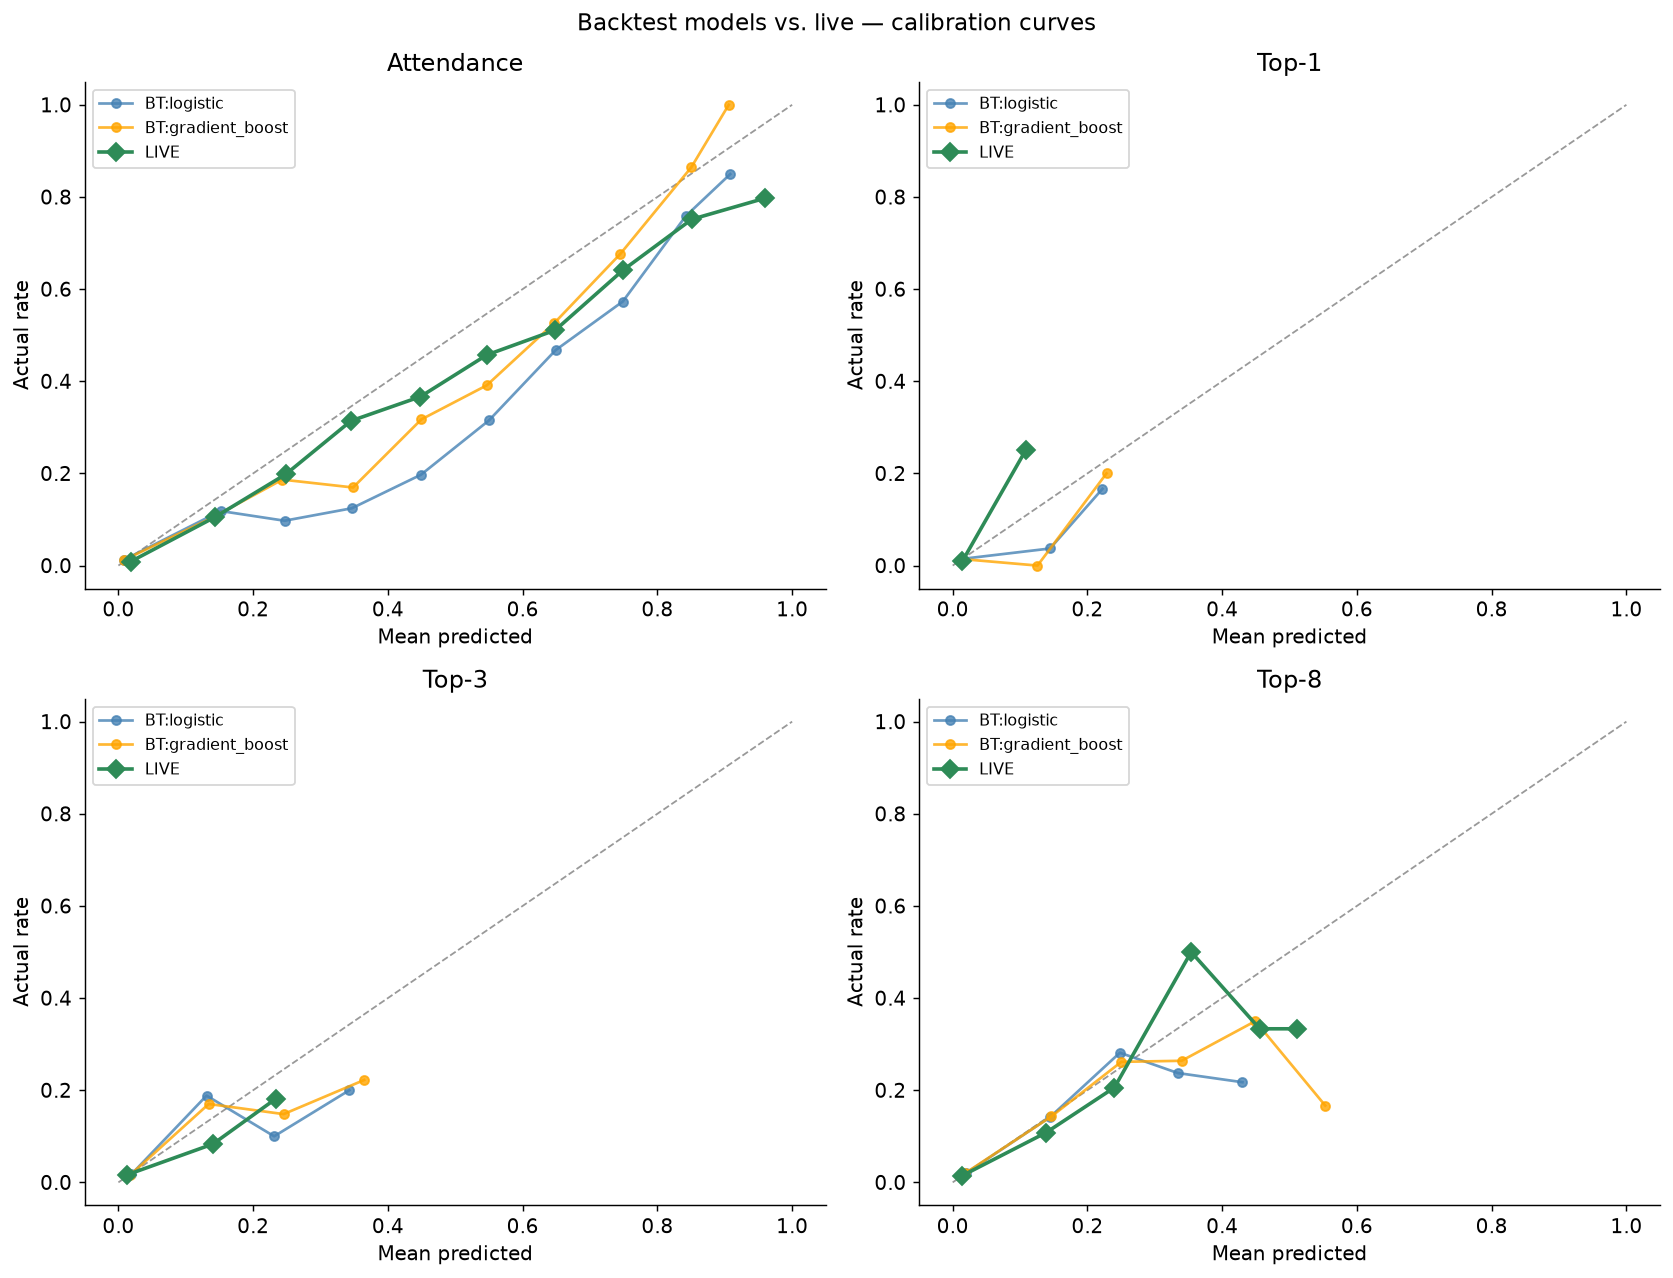

In [45]:
# Calibration curves: best backtest models vs live
COMPARE_MODELS = ['logistic', 'gradient_boost']
COLORS = {'logistic': 'steelblue', 'gradient_boost': 'orange', 'LIVE': 'seagreen'}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for idx, (pred_col, true_col, label) in enumerate(compare_metrics):
    ax = axes[idx // 2][idx % 2]
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)

    for model in COMPARE_MODELS:
        grp   = bt[bt['model'] == model]
        valid = grp[[pred_col, true_col]].dropna()
        if pred_col != 'p_participate':
            valid = valid[valid[pred_col] > 0.001]
        if len(valid) < 50:
            continue
        bins  = np.linspace(0, 1, N_BINS + 1)
        idxs  = np.digitize(valid[pred_col].values, bins, right=True)
        xs, ys = [], []
        for b in range(1, N_BINS + 1):
            mask = idxs == b
            if mask.sum() < 5:
                continue
            xs.append(valid[pred_col].values[mask].mean())
            ys.append(valid[true_col].values[mask].mean())
        ax.plot(xs, ys, 'o-', ms=5, lw=1.5, color=COLORS.get(model, 'gray'),
                label=f'BT:{model}', alpha=0.8)

    # Live model
    valid_live = df[[pred_col, true_col]].dropna()
    if pred_col != 'p_participate':
        valid_live = valid_live[valid_live[pred_col] > 0.001]
    if len(valid_live) >= 5:
        bins  = np.linspace(0, 1, N_BINS + 1)
        idxs  = np.digitize(valid_live[pred_col].values, bins, right=True)
        xs, ys = [], []
        for b in range(1, N_BINS + 1):
            mask = idxs == b
            if mask.sum() < 3:
                continue
            xs.append(valid_live[pred_col].values[mask].mean())
            ys.append(valid_live[true_col].values[mask].mean())
        ax.plot(xs, ys, 'D-', ms=7, lw=2, color=COLORS['LIVE'], label='LIVE', zorder=5)

    ax.set_xlabel('Mean predicted')
    ax.set_ylabel('Actual rate')
    ax.set_title(label)
    ax.legend(fontsize=9)

fig.suptitle('Backtest models vs. live — calibration curves', fontsize=13)
plt.tight_layout()
plt.show()

In [46]:
# Summary scorecard
print("=" * 60)
print("PERFORMANCE AUDIT SUMMARY")
print("=" * 60)
print(f"Live period : {LIVE_START} to 2026-09-08")
print(f"Tournaments : {df['tourn_date'].nunique()}")
print()
print("Calibration (live model)")
for s in [att_stats] + topn_stats:
    bss = s.get('brier_skill', float('nan'))
    bss_str = f", BSS={bss:.3f}" if not (bss != bss) else ''
    print(f"  {s['label']:30s}: Brier={s['brier']:.5f}, ECE={s['ece']:.5f}{bss_str}")
print()
print("Betting")
print(f"  Net P&L       : ${total_pnl:+.2f}")
print(f"  Total invested : ${total_cost:.2f}")
print(f"  ROI            : {roi:.1%}")
print(f"  Mean fill edge : {matched['edge'].mean():.4f}")
print(f"  Pct fills +edge: {(matched['edge'] > 0).mean():.1%}")

PERFORMANCE AUDIT SUMMARY
Live period : 2026-07-07 to 2026-09-08
Tournaments : 5

Calibration (live model)
  All players                   : Brier=0.03442, ECE=0.01762
  Top-1 | played                : Brier=0.00247, ECE=0.00080, BSS=0.118
  Top-3 | played                : Brier=0.00716, ECE=0.00405, BSS=0.142
  Top-5 | played                : Brier=0.01126, ECE=0.00447, BSS=0.186
  Top-8 | played                : Brier=0.01656, ECE=0.00550, BSS=0.245

Betting
  Net P&L       : $+9158.76
  Total invested : $23521.00
  ROI            : 38.9%
  Mean fill edge : 0.0532
  Pct fills +edge: 85.4%
